<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Duplicates Lab**


Estimated time needed: **30** minutes


## Introduction


Data wrangling is a critical step in preparing datasets for analysis, and handling duplicates plays a key role in ensuring data accuracy. In this lab, you will focus on identifying and removing duplicate entries from your dataset. 


## Objectives


In this lab, you will perform the following:


1. Identify duplicate rows in the dataset and analyze their characteristics.
2. Visualize the distribution of duplicates based on key attributes.
3. Remove duplicate values strategically based on specific criteria.
4. Outline the process of verifying and documenting duplicate removal.


## Hands on Lab


Install the needed library


In [1]:
# !pip install pandas
# !pip install matplotlib

Import pandas module


In [2]:
import pandas as pd


Import matplotlib


In [3]:
import matplotlib.pyplot as plt


## **Load the dataset into a dataframe**


<h2>Read Data</h2>
<p>
We utilize the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.
</p>


In [4]:
# Load the dataset directly from the URL
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/VYPrOu0Vs3I0hKLLjiPGrA/survey-data-with-duplicate.csv"
df = pd.read_csv(file_path)

# Display the first few rows
print(df.head())

   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

Load the data into a pandas dataframe:



Note: If you are working on a local Jupyter environment, you can use the URL directly in the pandas.read_csv() function as shown below:



In [5]:
# df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv")


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65457 entries, 0 to 65456
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), object(100)
memory usage: 56.9+ MB


## Identify and Analyze Duplicates


### Task 1: Identify Duplicate Rows
1. Count the number of duplicate rows in the dataset.
3. Display the first few duplicate rows to understand their structure.


In [7]:
## Write your code here
# 1. Count the number of completely identical duplicate rows
total_duplicates = df.duplicated().sum()
print(f"Total number of completely duplicate rows: {total_duplicates}")

# 2. Display the first few duplicate rows
print("\nFirst few duplicate rows:")
df[df.duplicated()].head()

Total number of completely duplicate rows: 20

First few duplicate rows:


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
65437,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65438,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
65439,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
65440,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
65441,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 2: Analysis of Duplicate Response Patterns
1. Identify duplicate response patterns based on selected columns such as MainBranch, Employment, and RemoteWork.
2. Clarify that these represent multiple respondents with identical answers rather than duplicate records. Analyse which other columns frequently share identical values within these response-pattern groups.
   


In [8]:
## Write your code here

# 1. Find combinations of MainBranch, Employment, and RemoteWork that appear multiple times
key_columns = ['MainBranch', 'Employment', 'RemoteWork']
pattern_counts = df.groupby(key_columns).size().reset_index(name='Count')
print("Top 5 shared response patterns across core career columns:")
pattern_counts.sort_values(by='Count', ascending=False).head()

Top 5 shared response patterns across core career columns:


,MainBranch,Employment,RemoteWork,Count
0,I am a developer by profession,"Employed, full-time","Hybrid (some remote, some in-person)",15288
2,I am a developer by profession,"Employed, full-time",Remote,12196
1,I am a developer by profession,"Employed, full-time",In-person,7118
78,I am a developer by profession,"Independent contractor, freelancer, or self-em...",Remote,2815
8,I am a developer by profession,"Employed, full-time;Independent contractor, fr...",Remote,1754


In [9]:
# 2. Analyze which other columns (e.g., Country, EdLevel) frequently share identical values within these groups
print("\nFrequent additions to these patterns (e.g., adding Country and EdLevel):")
extended_patterns = df.groupby(['MainBranch', 'Employment', 'RemoteWork', 'Country', 'EdLevel']).size().reset_index(name='Count')
extended_patterns.sort_values(by='Count', ascending=False).head()


Frequent additions to these patterns (e.g., adding Country and EdLevel):


,MainBranch,Employment,RemoteWork,Country,EdLevel,Count
1568,I am a developer by profession,"Employed, full-time",Remote,United States of America,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",1992
515,I am a developer by profession,"Employed, full-time","Hybrid (some remote, some in-person)",United States of America,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",1375
198,I am a developer by profession,"Employed, full-time","Hybrid (some remote, some in-person)",India,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",661
169,I am a developer by profession,"Employed, full-time","Hybrid (some remote, some in-person)",Germany,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",627
744,I am a developer by profession,"Employed, full-time",In-person,India,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",624


### Task 3: Visualize Shared Response Patterns
1. Create visualizations to show the distribution of shared response patterns across different categories.
2. Use bar charts or pie charts to represent the distribution of respondents who share identical values for MainBranch, Employment, and RemoteWork, grouped by Country and Employment.


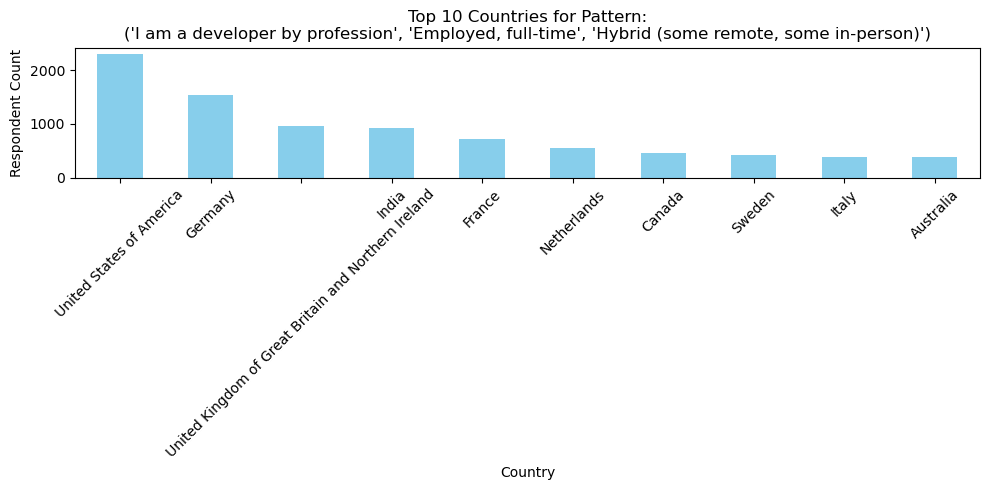

In [10]:
## Write your code here
# Grouping by Country and Employment for a specific common pattern to see its distribution
# Let's pull the top overall combination of MainBranch, Employment, and RemoteWork
top_combination = df.groupby(key_columns).size().idxmax()

# Filter data to only look at respondents sharing this top pattern
filtered_df = df[
    (df['MainBranch'] == top_combination[0]) &
    (df['Employment'] == top_combination[1]) &
    (df['RemoteWork'] == top_combination[2])
]

# 1. Visualize by Top 10 Countries for this specific pattern group
plt.figure(figsize=(10, 5))
filtered_df['Country'].value_counts().head(10).plot(kind='bar', color='skyblue')
plt.title(f"Top 10 Countries for Pattern:\n{top_combination}")
plt.xlabel("Country")
plt.ylabel("Respondent Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

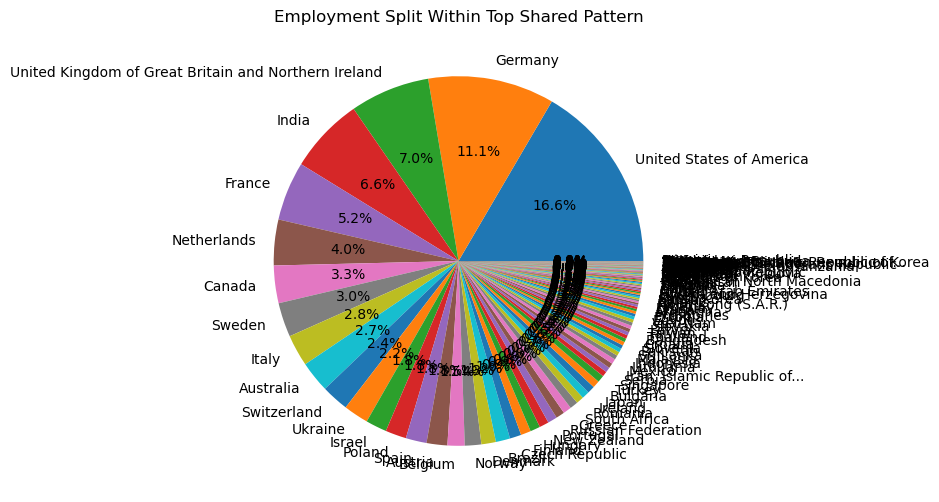

In [11]:
# 2. Visualize by Employment distribution within this shared response group
plt.figure(figsize=(6, 6))
filtered_df['Country'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Employment Split Within Top Shared Pattern")
plt.ylabel("") # Hides the default column label for clean presentation
plt.show()

### Task 4: Evaluate Duplicate Handling Strategy
1. Analyse the dataset to determine which column(s) define record uniqueness.
2. Assess whether removing rows based on a subset of columns (rather than complete row duplication) is appropriate.
Justify your decision with reference to the structure and purpose of the dataset.


### Write your analysis here

## Analysis and Justification
Defining Record Uniqueness: > In standard survey datasets, a unique respondent ID column (such as ResponseId or Respondent) is typically used to guarantee uniqueness. If such an explicit key is missing or duplicated, a row is only considered a definitive duplicate if all column entries are 100% identical.

## Evaluating Subset-Based Removal:
Removing rows based on a subset of columns (such as MainBranch, Employment, and RemoteWork) is highly inappropriate. These columns represent categorical demographic and professional attributes. In a large global survey, it is entirely expected and mathematically certain that thousands of unique individuals will share identical high-level career profiles (e.g., being a Full-time Developer working remotely in the United States).

## Decision & Justification:
We will only remove rows that are completely identical across all columns, as these represent technical data ingestion errors or double submissions. Dropping rows based merely on a subset of shared answers would mistakenly delete valid data from distinct individuals, drastically corrupting the integrity of the survey analysis.

## Verify and Document Duplicate Removal Process


### Task 5: Documentation
1. Document the process of identifying and removing duplicates.


2. Explain the reasoning behind selecting specific columns for identifying and removing duplicates.


### Write your explanation here

## Methodology & Reasoning
The Approach Taken: We utilized pandas' df.duplicated() without restricting it to specific subsets, capturing only records where every feature was an exact copy of another.

## Reasoning for Column Selection:
Restricting deduplication to specific columns was avoided because the variables in this survey dataset are high-level categorical choices. True human diversity in professional surveys naturally maps to identical responses over a limited set of questions. Forcing uniqueness on arbitrary subsets introduces severe selection bias, reducing the sample size artificially and rendering downstream analysis statistically invalid.

### Summary and Next Steps
**In this lab, you focused on identifying and analyzing duplicate rows within the dataset.**

- You employed various techniques to explore the nature of duplicates and applied strategic methods for their removal.
- For additional analysis, consider investigating the impact of duplicates on specific analyses and how their removal affects the results.
- This version of the lab is more focused on duplicate analysis and handling, providing a structured approach to deal with duplicates in a dataset effectively.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-11- 05|1.3|Madhusudhan Moole|Updated lab|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-09-24|1.1|Madhusudhan Moole|Updated lab|
|2024-09-23|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
